# AI Foundation: Camera to Embeddings
### read frames from a camera and display them with debug overlay

Imports and enviroment check

In [18]:
import sys
import time
from dataclasses import dataclass
from typing import Optional, Tuple

import cv2
import numpy as np

print("Python:", sys.version)
print("Opencv:", cv2.__version__)
print("Numpy:", np.__version__)

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Opencv: 4.13.0
Numpy: 2.4.2


camera configurations

In [13]:
@dataclass
class CameraConfiguration:
    camera_index: int = 0
    width: int = 1280
    height: int = 720
    target_fps: int = 30
    flip_horizontal: bool = False
    debug_window: str = "Camera Test"

FPS meter and Overlay

In [29]:
class FPSMeter:
    def __init__(self, smoothing: float = 0.9):
        self.smoothing = float(smoothing)
        self._last = None
        self._fps = 0.0  # ✅ initialize

    def update(self) -> float:
        now = time.time()
        if self._last is None:
            self._last = now
            return self._fps

        dt = now - self._last
        self._last = now

        inst = (1.0 / dt) if dt > 0 else 0.0
        self._fps = self._fps * self.smoothing + inst * (1.0 - self.smoothing)
        return self._fps


def create_overlay(frame: np.ndarray, fps: float, text: str = "") -> np.ndarray:
    out = frame.copy()
    message = f"FPS: {fps:5.1f}"
    if text:
        message += f" | {text}"
    cv2.putText(out, message, (10,30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2, cv2.LINE_AA)
    cv2.putText(out, "Press 'q' to quit", (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)
    return out


capturing the camera

In [30]:
def open_camera(cfg: CameraConfiguration) -> cv2.VideoCapture:
    cap = cv2.VideoCapture(cfg.camera_index, cv2.CAP_DSHOW)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open the camera on index {cfg.camera_index}")
    
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, cfg.width)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, cfg.height)
    cap.set(cv2.CAP_PROP_FPS, cfg.target_fps)

    return cap

def read_frame(cap: cv2.VideoCapture, cfg: CameraConfiguration) -> Optional[np.ndarray]:
    ok, frame = cap.read()
    if not ok or frame is None:
        return None

    if cfg.flip_horizontal:
        frame = cv2.flip(frame, 1)
    
    return frame

Replacing imshow() and destoryAllWindows()

In [31]:
from matplotlib import pyplot as plt
from IPython.display import clear_output

def show_frame_inline(bgr_img, title=None):
    rgb = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    clear_output(wait=True)
    plt.figure(figsize=(10, 6))
    if title:
        plt.title(title)
    plt.imshow(rgb)
    plt.axis("off")
    plt.show()

Camera Test Loop

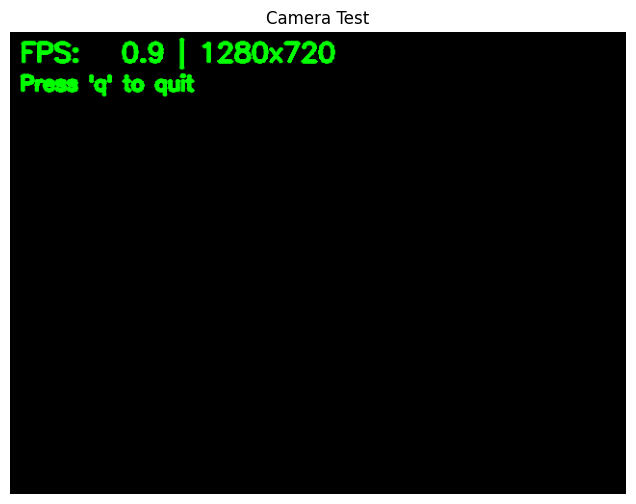

KeyboardInterrupt: 

In [32]:
def camera_test(cfg: CameraConfiguration, max_retries: int = 5):
    fps_meter = FPSMeter()
    retires = 0

    cap = None
    try:
        cap = open_camera(cfg)
        while True:
            frame = read_frame(cap, cfg)

            if frame is None:
                retires =+ 1
                print(f"Frame could not be read ({retires}/{max_retries}). trying to reopen camera again")
                if cap is not None:
                    cap.release()
                time.sleep(0.2)

                if retires > max_retires:
                    raise RuntimeError("Failed to read too many times.")
                cap = open_camera(cfg)
                continue

            retires = 0
            fps = fps_meter.update()

            display = create_overlay(frame, fps, text=f"{cfg.width}x{cfg.height}")
            show_frame_inline(display, title=cfg.debug_window)

            time.sleep(1 / cfg.target_fps) 
           
    finally:
        if cap is not None:
            cap.release()
        try:
            cv2.destroyAllWindows()
        except cv2.error:
            pass

cfg = CameraConfiguration(camera_index=0, width=1280, height=720, target_fps=30)
camera_test(cfg)